<a href="https://www.kaggle.com/code/sonawanelalitsunil/health-risk-prediction-using-anonymized-ml-97?scriptVersionId=257954674" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/health-risk-prediction-anonymized-real-data/Health_Risk_Dataset.csv


## Health Risk Prediction Using Anonymized Data

## Description:
This project focuses on predicting potential health risks by analyzing anonymized real-world medical and lifestyle data. The dataset includes demographic, clinical, and behavioral features such as age, BMI, chronic conditions, family history, lifestyle habits, and diagnostic details. By applying machine learning techniques, the goal is to identify patterns that can help forecast health risks, support early detection, and guide preventive measures while ensuring privacy and confidentiality of sensitive health information.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/health-risk-prediction-anonymized-real-data/Health_Risk_Dataset.csv")

In [3]:
df.head()

,Patient_ID,Respiratory_Rate,Oxygen_Saturation,O2_Scale,Systolic_BP,Heart_Rate,Temperature,Consciousness,On_Oxygen,Risk_Level
0,P0522,25,96,1,97,107,37.5,A,0,Medium
1,P0738,28,92,2,116,151,38.5,P,1,High
2,P0741,29,91,1,79,135,38.4,A,0,High
3,P0661,24,96,1,95,92,37.3,A,0,Medium
4,P0412,20,96,1,97,97,37.4,A,0,Low


In [4]:
df.tail()

,Patient_ID,Respiratory_Rate,Oxygen_Saturation,O2_Scale,Systolic_BP,Heart_Rate,Temperature,Consciousness,On_Oxygen,Risk_Level
995,P0107,18,96,1,124,72,37.2,A,0,Normal
996,P0271,19,95,1,129,70,38.1,A,0,Low
997,P0861,39,82,1,101,137,37.5,A,1,High
998,P0436,15,92,1,106,108,38.6,A,0,Medium
999,P0103,16,97,1,130,76,36.4,A,0,Normal


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Patient_ID         1000 non-null   object 
 1   Respiratory_Rate   1000 non-null   int64  
 2   Oxygen_Saturation  1000 non-null   int64  
 3   O2_Scale           1000 non-null   int64  
 4   Systolic_BP        1000 non-null   int64  
 5   Heart_Rate         1000 non-null   int64  
 6   Temperature        1000 non-null   float64
 7   Consciousness      1000 non-null   object 
 8   On_Oxygen          1000 non-null   int64  
 9   Risk_Level         1000 non-null   object 
dtypes: float64(1), int64(6), object(3)
memory usage: 78.3+ KB


In [6]:
df.describe()

,Respiratory_Rate,Oxygen_Saturation,O2_Scale,Systolic_BP,Heart_Rate,Temperature,On_Oxygen
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,21.511000,92.59000,1.124000,106.160000,98.460000,37.921000,0.274000
std,5.287517,4.47302,0.329746,17.897562,19.694626,1.113696,0.446232
min,12.000000,74.00000,1.000000,50.000000,60.000000,35.600000,0.000000
25%,17.000000,90.00000,1.000000,94.000000,84.000000,37.100000,0.000000
50%,20.000000,94.00000,1.000000,109.000000,95.500000,37.800000,0.000000
75%,25.000000,96.00000,1.000000,119.000000,109.000000,38.600000,1.000000
max,40.000000,100.00000,2.000000,146.000000,163.000000,41.800000,1.000000


In [7]:
df.dtypes

Patient_ID            object
Respiratory_Rate       int64
Oxygen_Saturation      int64
O2_Scale               int64
Systolic_BP            int64
Heart_Rate             int64
Temperature          float64
Consciousness         object
On_Oxygen              int64
Risk_Level            object
dtype: object

In [8]:
df.shape

(1000, 10)

In [9]:
df.isnull().sum()

Patient_ID           0
Respiratory_Rate     0
Oxygen_Saturation    0
O2_Scale             0
Systolic_BP          0
Heart_Rate           0
Temperature          0
Consciousness        0
On_Oxygen            0
Risk_Level           0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.columns

Index(['Patient_ID', 'Respiratory_Rate', 'Oxygen_Saturation', 'O2_Scale',
       'Systolic_BP', 'Heart_Rate', 'Temperature', 'Consciousness',
       'On_Oxygen', 'Risk_Level'],
      dtype='object')

## Data visualizations

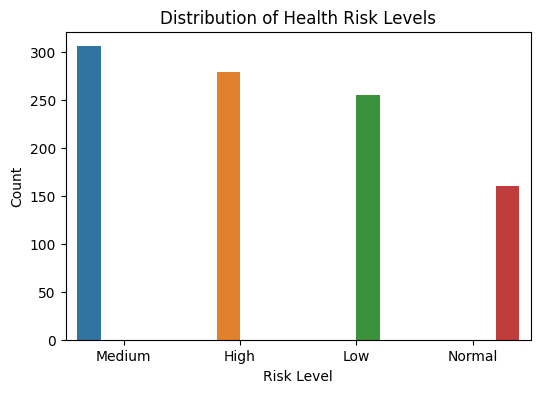

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Risk_Level", hue="Risk_Level")
plt.title("Distribution of Health Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.legend([],[], frameon=False)  # Hides duplicate legend
plt.show()

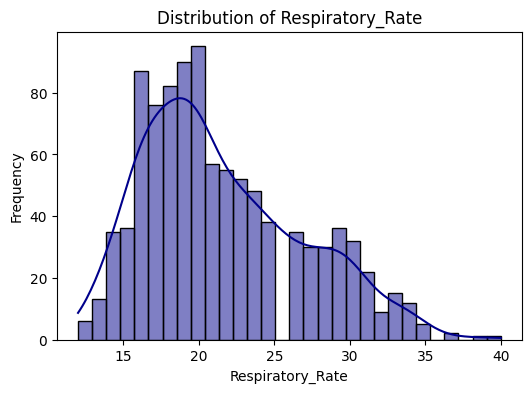

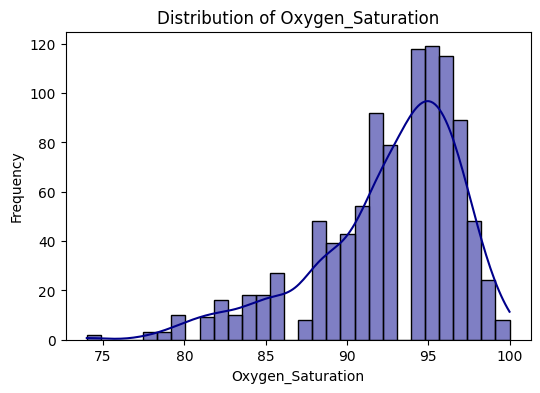

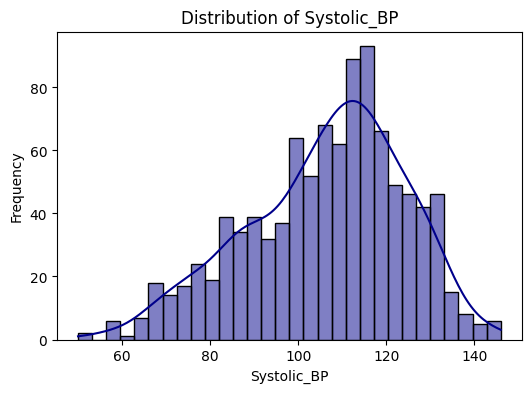

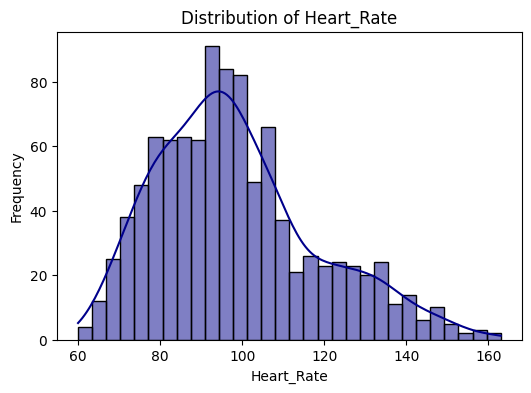

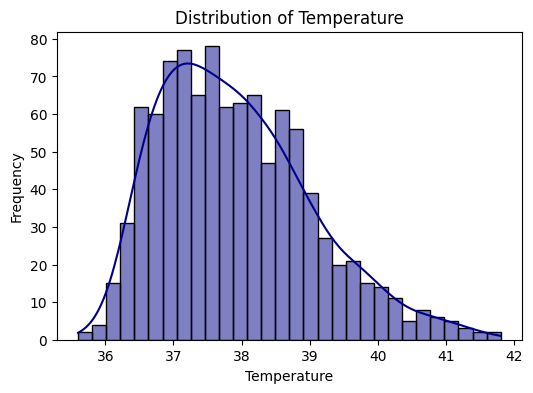

In [13]:
num_cols = ["Respiratory_Rate", "Oxygen_Saturation", "Systolic_BP", "Heart_Rate", "Temperature"]
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=30, kde=True, color="darkblue")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

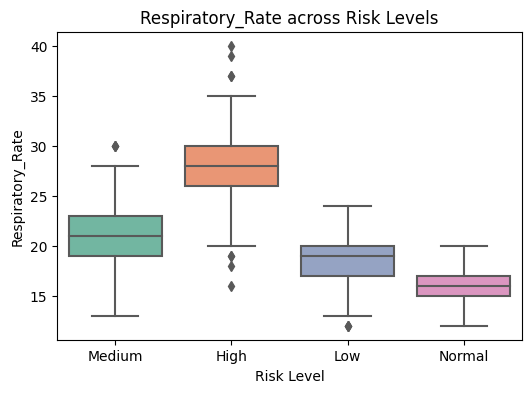

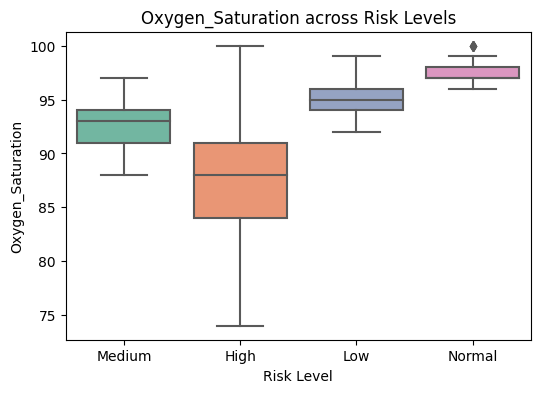

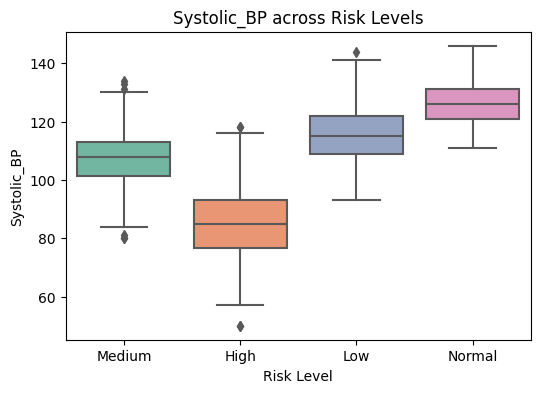

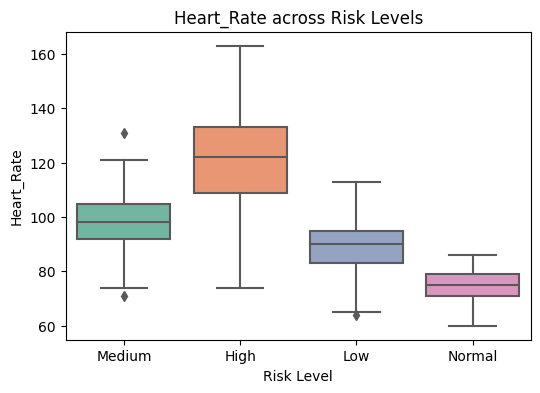

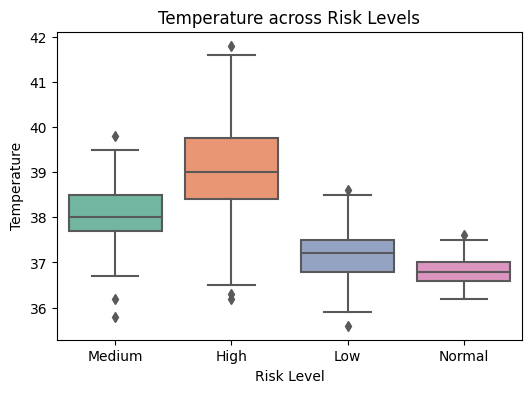

In [14]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x="Risk_Level", y=col, palette="Set2")
    plt.title(f"{col} across Risk Levels")
    plt.xlabel("Risk Level")
    plt.ylabel(col)
    plt.show()

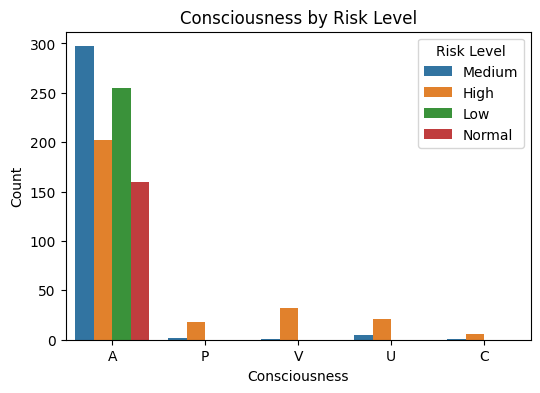

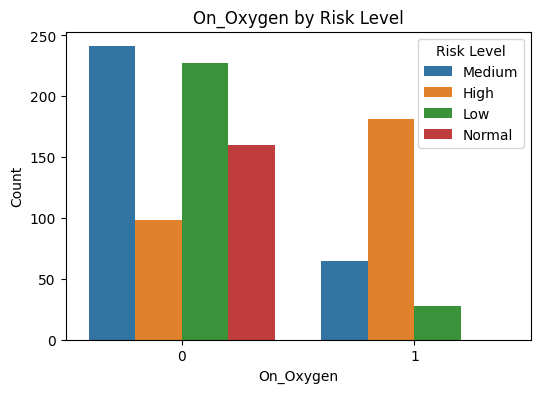

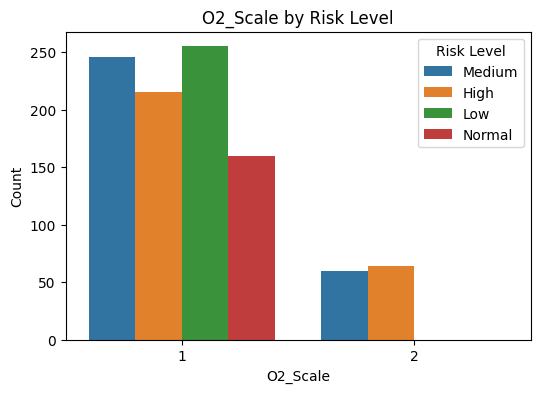

In [15]:
cat_cols = ["Consciousness", "On_Oxygen", "O2_Scale"]
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, hue="Risk_Level")
    plt.title(f"{col} by Risk Level")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title="Risk Level")
    plt.show()

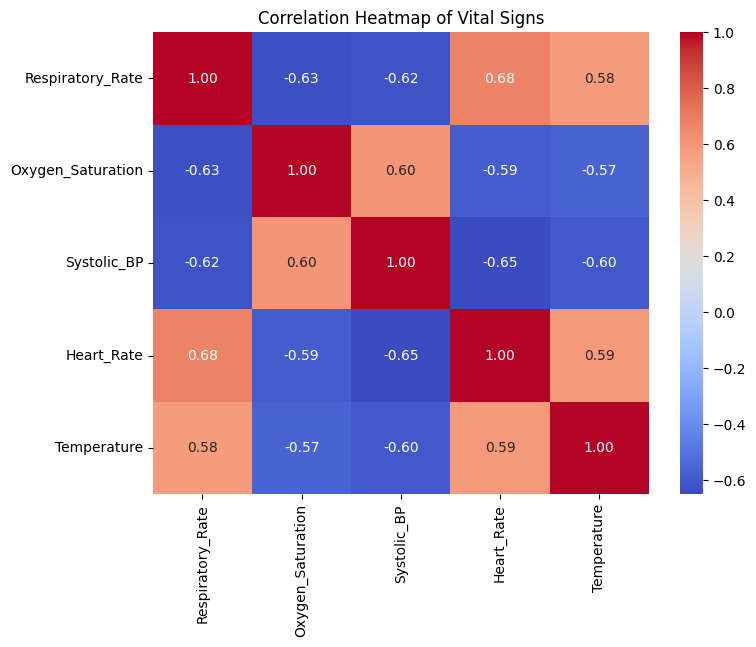

In [16]:
plt.figure(figsize=(8,6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Vital Signs")
plt.show()

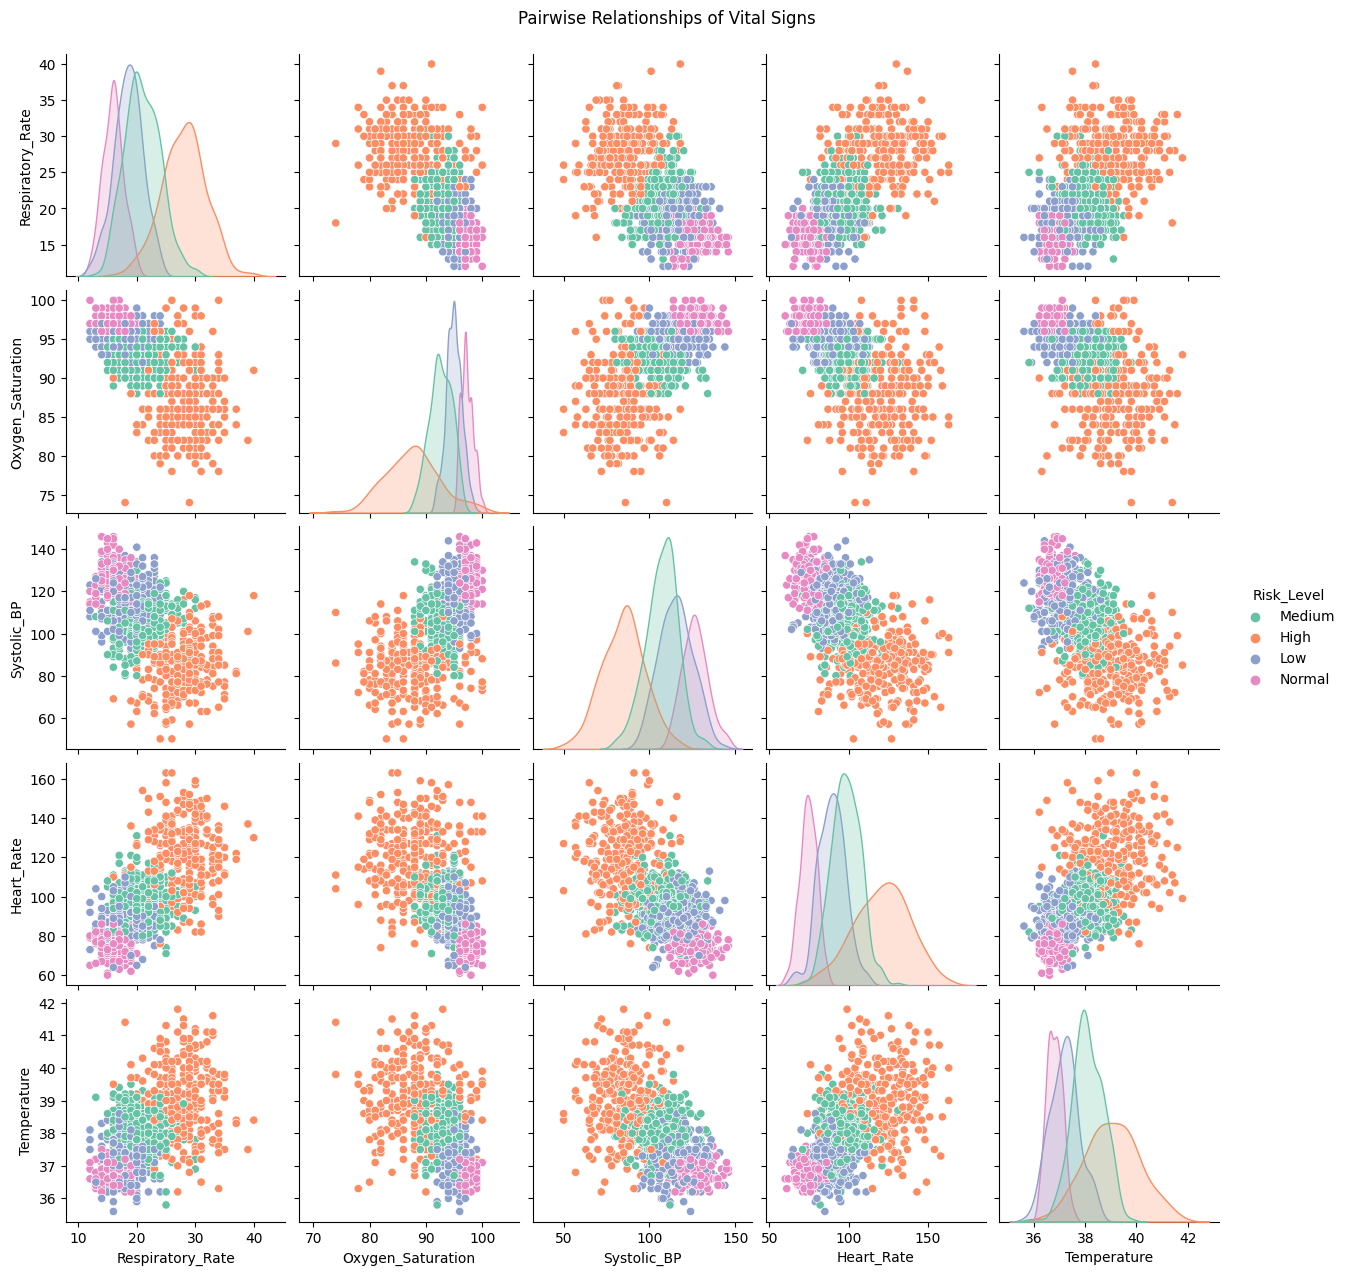

In [17]:
sns.pairplot(df[num_cols + ["Risk_Level"]], hue="Risk_Level", palette="Set2", diag_kind="kde")
plt.suptitle("Pairwise Relationships of Vital Signs", y=1.02)
plt.show()

## Predictive modeling

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [19]:
cat_cols = ["Consciousness", "On_Oxygen", "O2_Scale", "Risk_Level"]
le_dict = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

In [20]:
X = df.drop(columns=["Patient_ID", "Risk_Level"])
y = df["Risk_Level"]


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [22]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42)
}

In [23]:
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    results.append([name, acc])

In [24]:
results_df = pd.DataFrame(results, columns=["Algorithm", "Accuracy (%)"])
print(results_df)

             Algorithm  Accuracy (%)
0  Logistic Regression          96.5
1        Decision Tree          91.0
2        Random Forest          96.0
3    Gradient Boosting          97.0
4                  KNN          90.0
5                  SVM          84.0
6              XGBoost          95.0


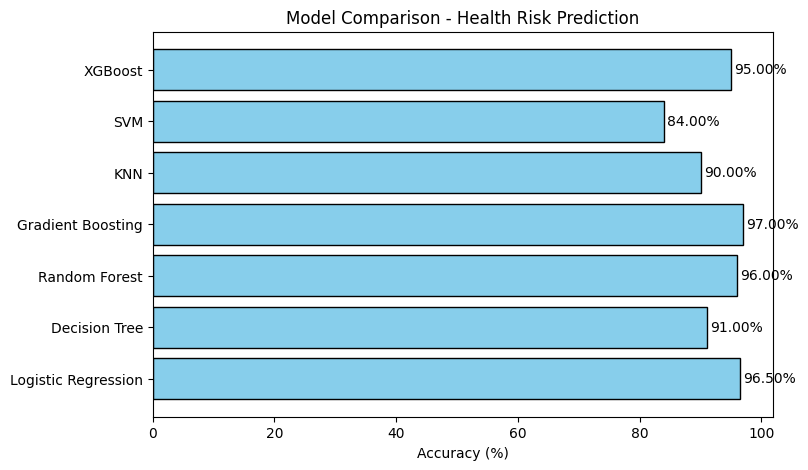

In [25]:
plt.figure(figsize=(8,5))
plt.barh(results_df["Algorithm"], results_df["Accuracy (%)"], color="skyblue", edgecolor="black")
plt.xlabel("Accuracy (%)")
plt.title("Model Comparison - Health Risk Prediction")
for index, value in enumerate(results_df["Accuracy (%)"]):
    plt.text(value + 0.5, index, f"{value:.2f}%", va='center')
plt.show()

## Thank you...pls upvote!!